### Linear Regression with unknown noise

This jupyter notebook contains an example of how to use bilby to perform parameter estimation for non-gravitational wave data. In this case, fitting a linear function to data with background Gaussian noise with unknown variance.

I have just translated [this Python script](https://github.com/bilby-dev/bilby/blob/main/examples/core_examples/linear_regression_unknown_noise.py) into a Jupyter notebook. All credits go to the original authors. 

In [1]:
# running this cell for the first time might take a little while
import bilby
import matplotlib.pyplot as plt
import numpy as np
from bilby.core.utils import random

In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="bilby"
)

In [3]:
# Sets seed of bilby's generator "rng" to "123" to ensure reproducibility
random.seed(123)

In [4]:
# A few simple setup steps
label = "linear_regression_unknown_noise"
outdir = "outdir"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)

In [5]:
# First, we define our "signal model", in this case a simple linear function
def model(time, m, c):
    return time * m + c

In [6]:
# Now we define the injection parameters which we make simulated data with
injection_parameters = dict(m=0.5, c=0.2)

In [7]:
# For this example, we'll inject standard Gaussian noise
sigma = 1

In [8]:
# These lines of code generate the fake data. Note the ** just unpacks the
# contents of the injection_parameters when calling the model function.
sampling_frequency = 10
time_duration = 10
time = np.arange(0, time_duration, 1 / sampling_frequency)
N = len(time)
data = model(time, **injection_parameters) + random.rng.normal(0, sigma, N)

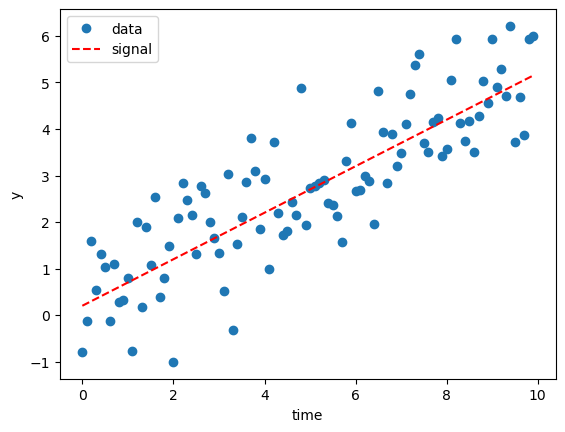

In [9]:
# We quickly plot the data to check it looks sensible
fig, ax = plt.subplots()
ax.plot(time, data, "o", label="data")
ax.plot(time, model(time, **injection_parameters), "--r", label="signal")
ax.set_xlabel("time")
ax.set_ylabel("y")
ax.legend()
fig.savefig("{}/{}_data.png".format(outdir, label))

In [10]:
injection_parameters.update(dict(sigma=sigma))

In [11]:
injection_parameters

{'m': 0.5, 'c': 0.2, 'sigma': 1}

In [12]:
# Now lets instantiate the built-in GaussianLikelihood, giving it
# the time, data and signal model. Note that, because we do not give it the
# parameter, sigma is unknown and marginalised over during the sampling
likelihood = bilby.core.likelihood.GaussianLikelihood(time, data, model)

In [13]:
# and set the priors
priors = dict()
priors["m"] = bilby.core.prior.Uniform(0, 5, "m")
priors["c"] = bilby.core.prior.Uniform(-2, 2, "c")
priors["sigma"] = bilby.core.prior.Uniform(0, 2, "sigma")

In [14]:
priors

{'m': Uniform(minimum=0, maximum=5, name='m', latex_label='m', unit=None, boundary=None),
 'c': Uniform(minimum=-2, maximum=2, name='c', latex_label='c', unit=None, boundary=None),
 'sigma': Uniform(minimum=0, maximum=2, name='sigma', latex_label='sigma', unit=None, boundary=None)}

In [15]:
# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="emcee",
    # MCMC sampling settings
    nsteps=500,
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    clean=True, 
)

17:09 bilby INFO    : Running for label 'linear_regression_unknown_noise', output will be saved to 'outdir'
17:09 bilby INFO    : Analysis priors:
17:09 bilby INFO    : m=Uniform(minimum=0, maximum=5, name='m', latex_label='m', unit=None, boundary=None)
17:09 bilby INFO    : c=Uniform(minimum=-2, maximum=2, name='c', latex_label='c', unit=None, boundary=None)
17:09 bilby INFO    : sigma=Uniform(minimum=0, maximum=2, name='sigma', latex_label='sigma', unit=None, boundary=None)
17:09 bilby INFO    : Analysis likelihood class: <class 'bilby.core.likelihood.GaussianLikelihood'>
17:09 bilby INFO    : Analysis likelihood noise evidence: nan
17:09 bilby INFO    : Single likelihood evaluation took 3.460e-05 s
17:09 bilby INFO    : Using sampler Emcee with kwargs {'nwalkers': 500, 'a': 2, 'args': [], 'kwargs': {}, 'postargs': None, 'pool': None, 'live_dangerously': False, 'runtime_sortingfn': None, 'lnprob0': None, 'rstate0': None, 'blobs0': None, 'iterations': 500, 'thin': 1, 'storechain': Tru

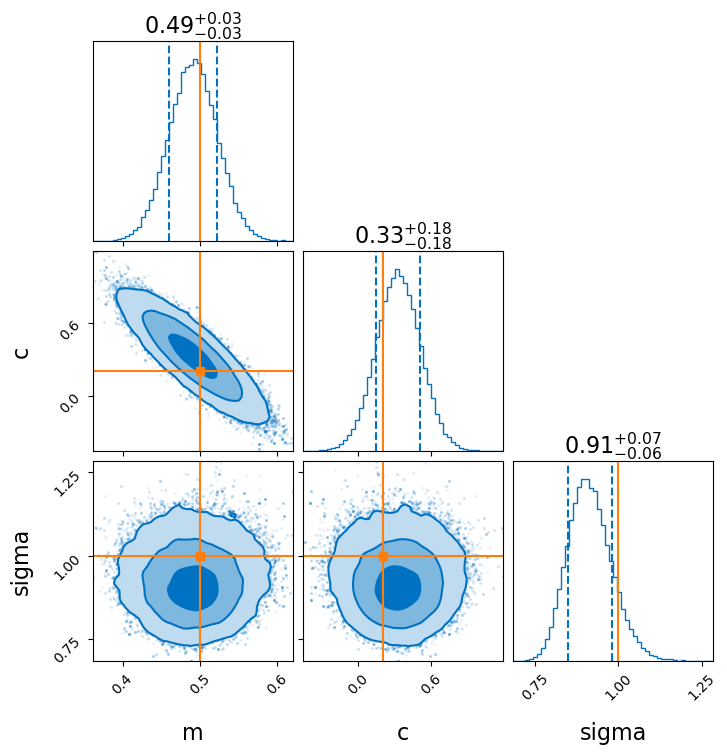

In [16]:
# Finally plot a corner plot: all outputs are stored in outdir
result.plot_corner()

In [17]:
# We select a subset of all posterior samples
posterior_samples = result.posterior.sample(1_000, random_state = 42)

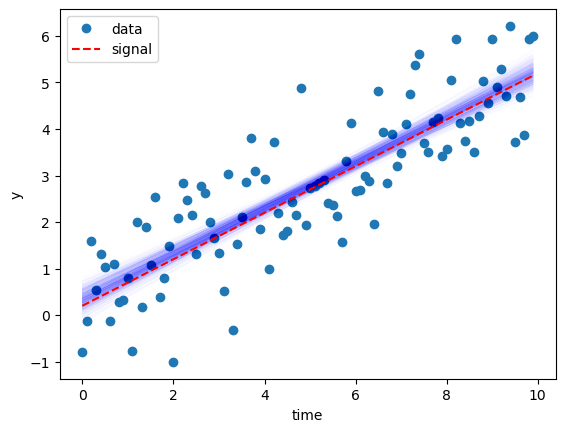

In [18]:
# We quickly plot the data and the inferred parameters to check if fit looks sensible
fig, ax = plt.subplots()
ax.plot(time, data, "o", label="data")
for c, m in zip(posterior_samples['m'], posterior_samples['c']):
    #print(c,m)
    ax.plot(time, model(time, c, m), "b", alpha = 0.01, lw = 0.5) #, label="signal")

ax.plot(time, model(time, injection_parameters['m'], injection_parameters['c']), "--r", label="signal")
ax.set_xlabel("time")
ax.set_ylabel("y")
ax.legend()
fig.savefig("{}/{}_data_with_inference.png".format(outdir, label))

### Questions and exercises

_Hint: rename always the output folder when rerunning, otherwise the `bilby` will use stored results by default_

- did you check the MCMC diagnostics? Did the run converged well? How can you check this?
- what happens if you increase the number of steps? 
- what happens if you increase noise? Rerun the entire notebook by increasing the value of `sigma`.
